# 04 — Centered Gibbs states: a no-crossing theorem for mean energy

Companion to the thermal no-crossing result. The derivation is kept analytical first and then checked numerically for several temperatures.


## Guiding question
Can two centered Gibbs preparations of the same linear circuit cross in their mean excess energy during relaxation?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, solve_continuous_lyapunov
np.set_printoptions(precision=6, suppress=True)


For a centered equilibrium preparation at temperature $T_i$ in a circuit coupled to a bath at $T_b$,
$$
\Sigma_i=k_BT_iG^{-1},\qquad \Sigma_b=k_BT_bG^{-1}.
$$
With $P(t)=e^{At}$,
$$
\langle E(t)\rangle=k_BT_b+(T_i-T_b)f(t),
$$
where
$$
f(t)=\frac{k_B}{2}\operatorname{Tr}[G P(t)G^{-1}P^T(t)]>0.
$$
All centered Gibbs preparations share the same positive relaxation function, so their energy ordering cannot cross.


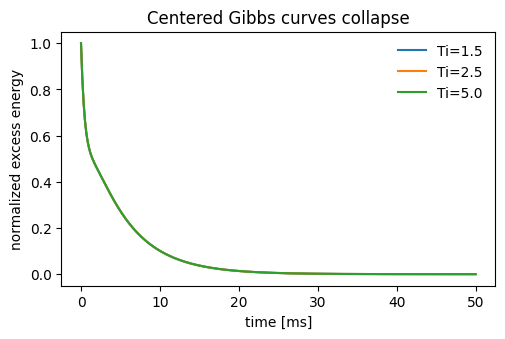

centered-Gibbs no-crossing check: PASS


In [2]:
L=0.100; C=100e-6; R=110.; kB=1.0; Tb=1.0
A=np.array([[0.,1.],[-1/(L*C),-R/L]])
G=np.diag([1/C,L]); Gi=np.linalg.inv(G)
t=np.linspace(0,0.05,300)
f=[]
for tt in t:
    P=expm(A*tt)
    f.append(0.5*np.trace(G@P@Gi@P.T))
f=np.array(f)
assert np.all(f>0)
Tis=[1.5,2.5,5.0]
curves=[]
for Ti in Tis:
    curves.append(Tb+(Ti-Tb)*f)
for i in range(len(Tis)-1):
    assert np.all(np.sign(curves[i+1]-curves[i])==1)
fig,ax=plt.subplots(figsize=(5.6,3.3))
for Ti,E in zip(Tis,curves): ax.plot(1e3*t,(E-Tb)/(Ti-Tb),label=f'Ti={Ti}')
ax.set(xlabel='time [ms]',ylabel='normalized excess energy',title='Centered Gibbs curves collapse'); ax.legend(frameon=False); plt.show()
print('centered-Gibbs no-crossing check: PASS')


## Why this matters
The negative result is structural, not a failed parameter search. Changing only the initial temperature rescales the excess energy but does not change its time dependence. A crossing requires nonequilibrium structure beyond temperature alone.


## Reader exploration
1. Add more initial temperatures and verify that the normalized excess-energy curves still collapse. 2. Replace the Gibbs covariance by an anisotropic covariance and identify exactly which assumption of the no-crossing result has been broken.
